In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

from randomness import *
from df_metrics import *
from simulation_exact import *
from utils import *
from data_analysis import *
from main import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from joblib import Parallel, delayed
from itertools import product

#seed = 42
#np.random.seed(seed)
#rng = np.random.default_rng(seed)

In [4]:
use_loss = 'hinge' #'log' or 'hinge' or 'squared_hinge' 
sigma_loss = 1.0 
c = 1.0 # choose c without scaling 
show_plots = False # set to True to see plots of the binary search
is_throw = True # set to True to throw out points outside margin --> only when loss is lipschitz. 
k = None # if none will be set based on data max norm
k_coef = 1.0 # coefficient to multiply k with
fit_intercept = True # whether to fit intercept in SVM model
ds = [2, 4, 8, 16, 32, 64] # dimensions to run experiments on
T = 200  # number of trials

In [5]:
def generate_gaus_data(n_pos, n_neg, mu_pos, mu_neg, sigma_pos, sigma_neg, rng, d=1):
    X_neg = rng.normal(loc=mu_neg, scale=sigma_neg, size=(n_neg, d)) # label -1 
    X_pos = rng.normal(loc=mu_pos, scale=sigma_pos, size=(n_pos, d)) # label 1 
    X = np.vstack([X_neg, X_pos])
    y = np.concatenate([-1 * np.ones(n_neg),np.ones(n_pos)])

    v = np.concatenate([np.ones(n_pos + n_neg)])  # generate_v_data(n_neg, n_pos, rng)
    return X, y, v

In [6]:
# choose parameters 
n_pos = 50 # number of data points in a sample with label 1
n_neg = 50 # number of data points in a sample with label -1
n_val_pos = 200
n_val_neg = 200
sigma_pos = 1.0
sigma_neg = 1.0
mus = np.linspace(3, 0, 31) # different sigmas to run the experiments on

In [7]:
# run exact sisigmalation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_gaus_1(t):
    dfs = []
    for d in ds:
        for mu_scalar in mus:
            mu = np.concatenate(([mu_scalar], np.zeros(d - 1)))
            seed = hash((t, d, mu_scalar)) % (2**32)
            rng = np.random.default_rng(seed)
            x, y, v = generate_gaus_data(n_pos, n_neg, mu, -mu, sigma_pos/ np.sqrt(d), sigma_neg/ np.sqrt(d), rng, d)
            #x_val, y_val, _ = generate_gaus_data(n_val_pos, n_val_neg, mu, -mu, sigma_pos/ np.sqrt(d), sigma_neg/ np.sqrt(d), rng, d)
            
            df_exact, svm_model = run_exact(x, y, v, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
            df_exact['t'] = t
            df_exact['d'] = d
            df_exact['mu'] = mu_scalar
            #df_exact['valid_acc'] = svm_model.score(x_val,y_val)
            df_exact['label'] = y[df_exact['agent'].astype(int)]
            dfs.append(df_exact)

    return pd.concat(dfs, ignore_index=True)

In [58]:
is_throw = True
mega_df_mu_T = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_1)(t) for t in range(T)
        ), 
        ignore_index=True
)

In [59]:
is_throw = False
mega_df_mu_F = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_1)(t) for t in range(T)
        ), 
        ignore_index=True
)

In [60]:
mega_df_mu_T

,agent,allocation,true_v,critical_v,welfare,utility,is_relevant,support,is_throw,t,d,mu,label
0,0,1,1.0,0.000000,1.0,1.000000,0,0,1,0,2,3.0,-1.0
1,1,1,1.0,0.000000,1.0,1.000000,0,0,0,0,2,3.0,-1.0
2,2,1,1.0,0.000000,1.0,1.000000,0,0,1,0,2,3.0,-1.0
3,3,1,1.0,0.000000,1.0,1.000000,0,0,1,0,2,3.0,-1.0
4,4,1,1.0,0.000000,1.0,1.000000,0,0,1,0,2,3.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3719995,95,1,1.0,0.577646,1.0,0.422354,1,1,0,199,64,0.0,1.0
3719996,96,1,1.0,0.000000,1.0,1.000000,1,1,0,199,64,0.0,1.0
3719997,97,1,1.0,0.670769,1.0,0.329231,1,1,0,199,64,0.0,1.0
3719998,98,1,1.0,0.356038,1.0,0.643962,1,1,0,199,64,0.0,1.0


In [61]:
mega_df_mu_F

,agent,allocation,true_v,critical_v,welfare,utility,is_relevant,support,is_throw,t,d,mu,label
0,0,1,1.0,0.000000,1.0,1.000000,0,0,0,0,2,3.0,-1.0
1,1,1,1.0,0.000000,1.0,1.000000,0,0,0,0,2,3.0,-1.0
2,2,1,1.0,0.000000,1.0,1.000000,0,0,0,0,2,3.0,-1.0
3,3,1,1.0,0.000000,1.0,1.000000,0,0,0,0,2,3.0,-1.0
4,4,1,1.0,0.000000,1.0,1.000000,0,0,0,0,2,3.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3719995,95,1,1.0,0.577646,1.0,0.422354,1,1,0,199,64,0.0,1.0
3719996,96,1,1.0,0.000000,1.0,1.000000,1,1,0,199,64,0.0,1.0
3719997,97,1,1.0,0.670769,1.0,0.329231,1,1,0,199,64,0.0,1.0
3719998,98,1,1.0,0.356038,1.0,0.643962,1,1,0,199,64,0.0,1.0


In [62]:
cols = ["agent", "true_v", "is_relevant", "support", "t", "d", "mu", "label"]

merged_df = pd.merge(
    mega_df_mu_T,
    mega_df_mu_F,
    on=cols,
    how="inner",
    suffixes=("_T", "_F")
)


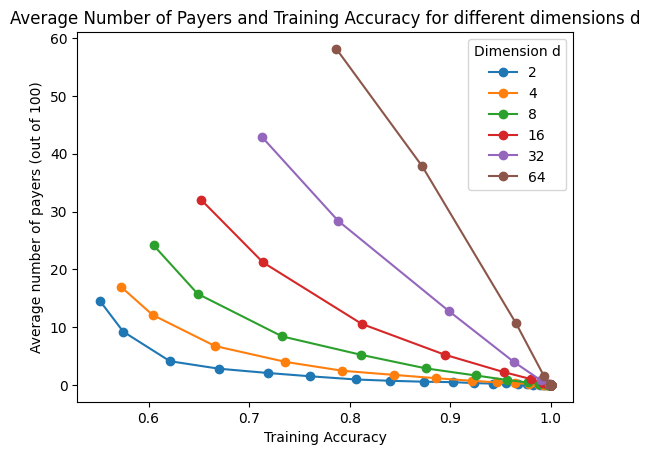

In [23]:
acc_num_payers(mega_df_mu, 'mu', T, labels = [1, -1])

In [1]:
acc_num_payers(mega_df_mu_T, 'mu', T, labels = [1, -1])
acc_2(mega_df_mu_T, 'mu', T, [32], labels = [1, -1])
plot_mean_payment(mega_df_mu_T, 'mu', labels = [1, -1])

NameError: name 'acc_num_payers' is not defined

In [9]:
ds = [4]
mus = [mus[-3]]
df = compute_metrics_gaus_1(198)

margin, beta [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 17 19 21 22 24 25 26 27
 28 29 31 32 33 35 36 37 38 41 42 43 46 47 48 49 50 55 56 57 59 63 66 67
 68 69 70 71 72 73 74 77 78 79 80 81 82 84 86 87 88 89 90 91 93 95 96 97
 98] [0.19499708 0.07525372 0.05868513 0.27722064 0.00599498 0.25635084
 0.05913863 0.05407385 0.161284   0.10723928 0.27167452 0.20439857
 0.39130523 0.23463521 0.01926881 0.24461046 0.3833014  0.03907922
 0.04785295 0.32902056 0.15866951 0.1382711  0.37454775 0.23264354
 0.05220653 0.15844921 0.1790961  0.277505   0.26077176 0.02398897
 0.09097222 0.00452362 0.34511348 0.06571427 0.34941568 0.13101318
 0.18886635 0.0259419  0.34130513 0.06121364 0.44352567 0.10842207
 0.3789288  0.08927765 0.31372815 0.25090759 0.2562791  0.08537284
 0.10205318 0.09372635 0.2980214  0.04366411 0.44873521 0.04004461
 0.13923402 0.06734758 0.04664679 0.09835333 0.0144954  0.23175895
 0.16569193 0.2573528  0.40436929 0.05510324 0.07164251 0.19158233
 0.23289755 0.41932348 0.1

In [ ]:
[ 3  4  5  6  7  8  9 14 16 17 18 20 21 23 24 26 27 28 29 30 32 33 34 35
 37 38 39 40 44 47 49 52 54 56 57 58 59 60 61 62 63 64 65 66 68 72 73 74
 78 79 81 82 83 84 87 88 91 92 93 94 96 97 98] 

 
[ 0.11006108  0.04164093  0.01767846 -0.00732798  0.03451953  0.03688919
 -0.00158252  0.04097333 -0.01565597  0.1645238   0.02509166  0.0383508
  0.0023375   0.01767448  0.15131164  0.06159829  0.13313078  0.07147381
  0.22466367  0.09017295  0.02073146  0.22195183  0.00563656  0.01303066
  0.00790472  0.06573568  0.00623091  0.02172462  0.09756609  0.04225237
  0.02497992  0.15391209 -0.02018429  0.01592692 -0.00530585  0.09088258
  0.08945246  0.05343605 -0.00698599 -0.0077137   0.04674696  0.06891805
  0.03120272  0.03277016  0.03763706  0.0759463  -0.01466695  0.05697806
  0.08627716  0.06690805  0.03348182  0.0600843   0.08504883  0.00153271
  0.08608849  0.05056267  0.00544488 -0.00673096  0.08234957  0.08448079
  0.06268505  0.09417731  0.07266925]

In [63]:
import numpy as np

a = np.array(a)
b = np.array(b)
c = np.array(c)

# mask for elements of a that are in c
mask = np.isin(a, c)

# filtered a and corresponding b
a_filtered = a[mask]
b_filtered = b[mask]

# create d = b - beta (element-wise)
d = b_filtered - beta

print(a_filtered)
print(b_filtered)
print(max(d))


[ 0 12 16 23 24 27 36 41 43 46 55 57 60 61 68 69 70 73 74 75 81 86 87 91
 94 95 98]
[0.0147679  0.00992522 0.01402873 0.01412938 0.01610299 0.01729432
 0.00971086 0.01222041 0.0179977  0.00966859 0.01278061 0.01282366
 0.00936683 0.0131483  0.01012524 0.01898374 0.01802125 0.01053021
 0.01172797 0.01303593 0.01140003 0.0166895  0.00937665 0.01312941
 0.02001372 0.00919727 0.01369193]
0.011083884223137134


In [ ]:
0.014476059386789692
0.011083884223137134

In [74]:
df[
    (df['critical_v'] > 0) &
    (df['is_relevant'] == 0)  &
    (df['support'] == 1)  
]['agent'].tolist()

[]